In [274]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [275]:
df = pd.read_csv("titanic.csv")

In [276]:
df2 = df.copy()

In [277]:
df.shape

(418, 12)

In [278]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [279]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,B45,S
380,1272,0,3,"O'Connor, Mr. Patrick",male,NaN,0,0,366713,7.7500,NaN,Q
130,1022,0,3,"Spinner, Mr. Henry John",male,32.0,0,0,STON/OQ. 369943,8.0500,NaN,S
242,1134,0,1,"Spedden, Mr. Frederic Oakley",male,45.0,1,1,16966,134.5000,E34,C
108,1000,0,3,"Willer, Mr. Aaron (Abi Weller"")""",male,NaN,0,0,3410,8.7125,NaN,S


In [280]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [281]:
numerical_cols = df.select_dtypes(include = "number").columns
catagorical_cols = df.select_dtypes(include = "object").columns

In [282]:
numerical_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [283]:
catagorical_cols

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [284]:
from sklearn.impute import SimpleImputer

In [285]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [286]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [287]:
df.shape

(418, 12)

# EDA)

In [288]:
classes = df["Survived"].value_counts()

In [289]:
classes

Survived
0    266
1    152
Name: count, dtype: int64

Text(0.5, 1.0, ' survived people or not')

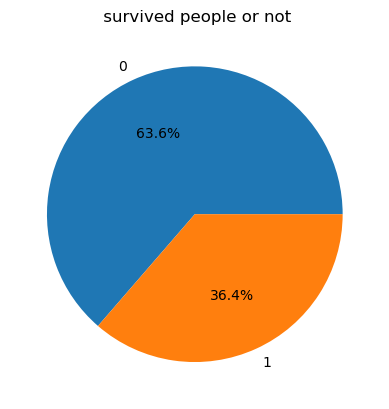

In [290]:
plt.pie(classes,labels = [0,1],autopct = "%1.1f%%")
plt.title(" survived people or not")

In [291]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

<Axes: xlabel='Sex', ylabel='count'>

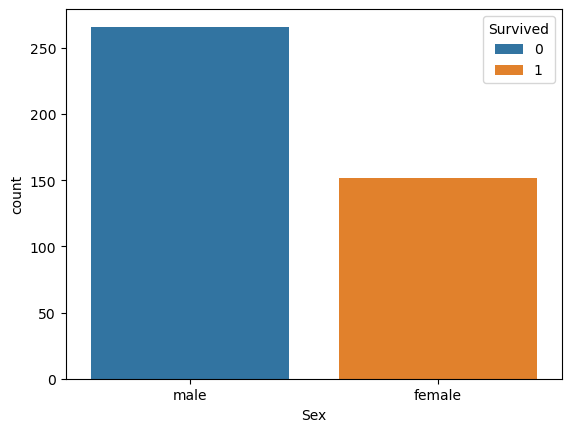

In [292]:
sns.countplot(data = df,x = "Sex",hue = "Survived")

[Text(0, 0, '266'), Text(0, 0, '152')]

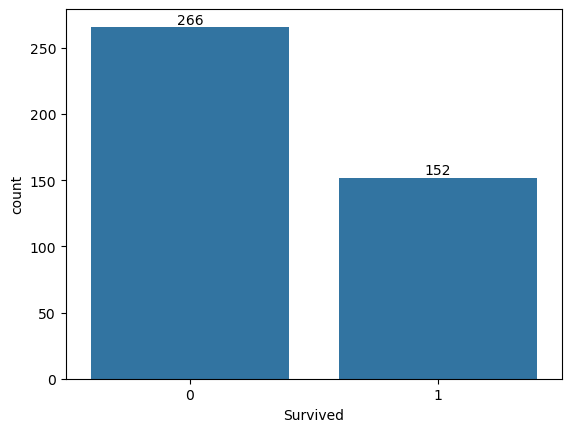

In [293]:
sr_cnt = df["Survived"].value_counts()
ax = sns.barplot(sr_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Pclass', ylabel='count'>

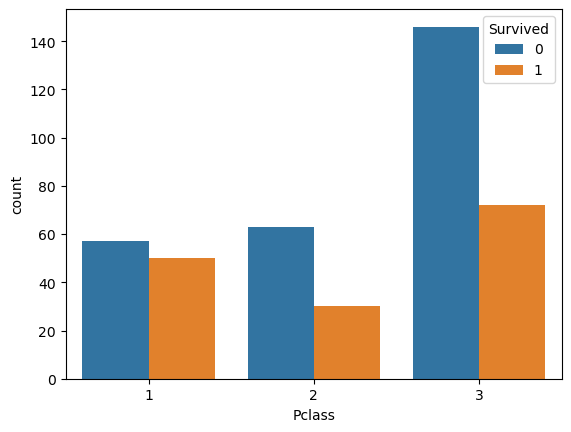

In [294]:
sns.countplot(data = df,x="Pclass", hue="Survived")

<Axes: xlabel='Age', ylabel='Count'>

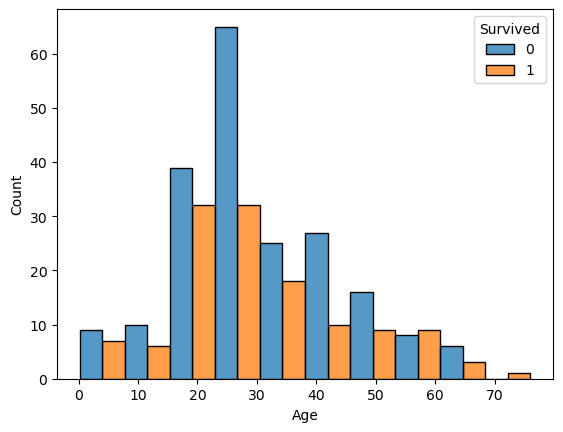

In [295]:
sns.histplot(data = df,x = "Age",hue = "Survived",multiple = "dodge",bins = 10)

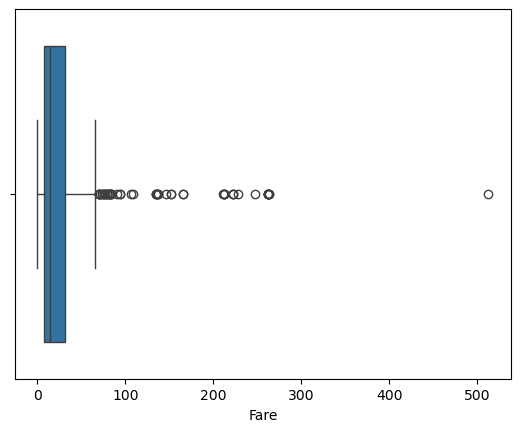

In [296]:
sns.boxplot(x=df['Fare'])
plt.show()

In [297]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [298]:
df = df.drop("PassengerId",axis = 1)

In [299]:
df = df.drop("Name",axis = 1)

In [300]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,male,34.5,0,0,330911,7.8292,NaN,Q
1,1,3,female,47.0,1,0,363272,7.0000,NaN,S
2,0,2,male,62.0,0,0,240276,9.6875,NaN,Q
3,0,3,male,27.0,0,0,315154,8.6625,NaN,S
4,1,3,female,22.0,1,1,3101298,12.2875,NaN,S


In [301]:
cols = ["Sex","Embarked"]
on = OneHotEncoder(drop = "first",sparse_output = False,handle_unknown = "ignore")
encoded = on.fit_transform(df[cols])

In [302]:
df = df.drop("Cabin",axis = 1)

In [303]:
encoded

array([[1., 1., 0.],
       [0., 0., 1.],
       [1., 1., 0.],
       ...,
       [1., 0., 1.],
       [1., 0., 1.],
       [1., 0., 0.]])

In [304]:
encoded_df = pd.DataFrame(encoded,columns = on.get_feature_names_out(cols),index = df.index)

In [305]:
df = pd.concat([df.drop(columns = cols),encoded_df],axis = 1)

In [306]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,34.5,0,0,330911,7.8292,1.0,1.0,0.0
1,1,3,47.0,1,0,363272,7.0000,0.0,0.0,1.0
2,0,2,62.0,0,0,240276,9.6875,1.0,1.0,0.0
3,0,3,27.0,0,0,315154,8.6625,1.0,0.0,1.0
4,1,3,22.0,1,1,3101298,12.2875,0.0,0.0,1.0


In [307]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

<Axes: >

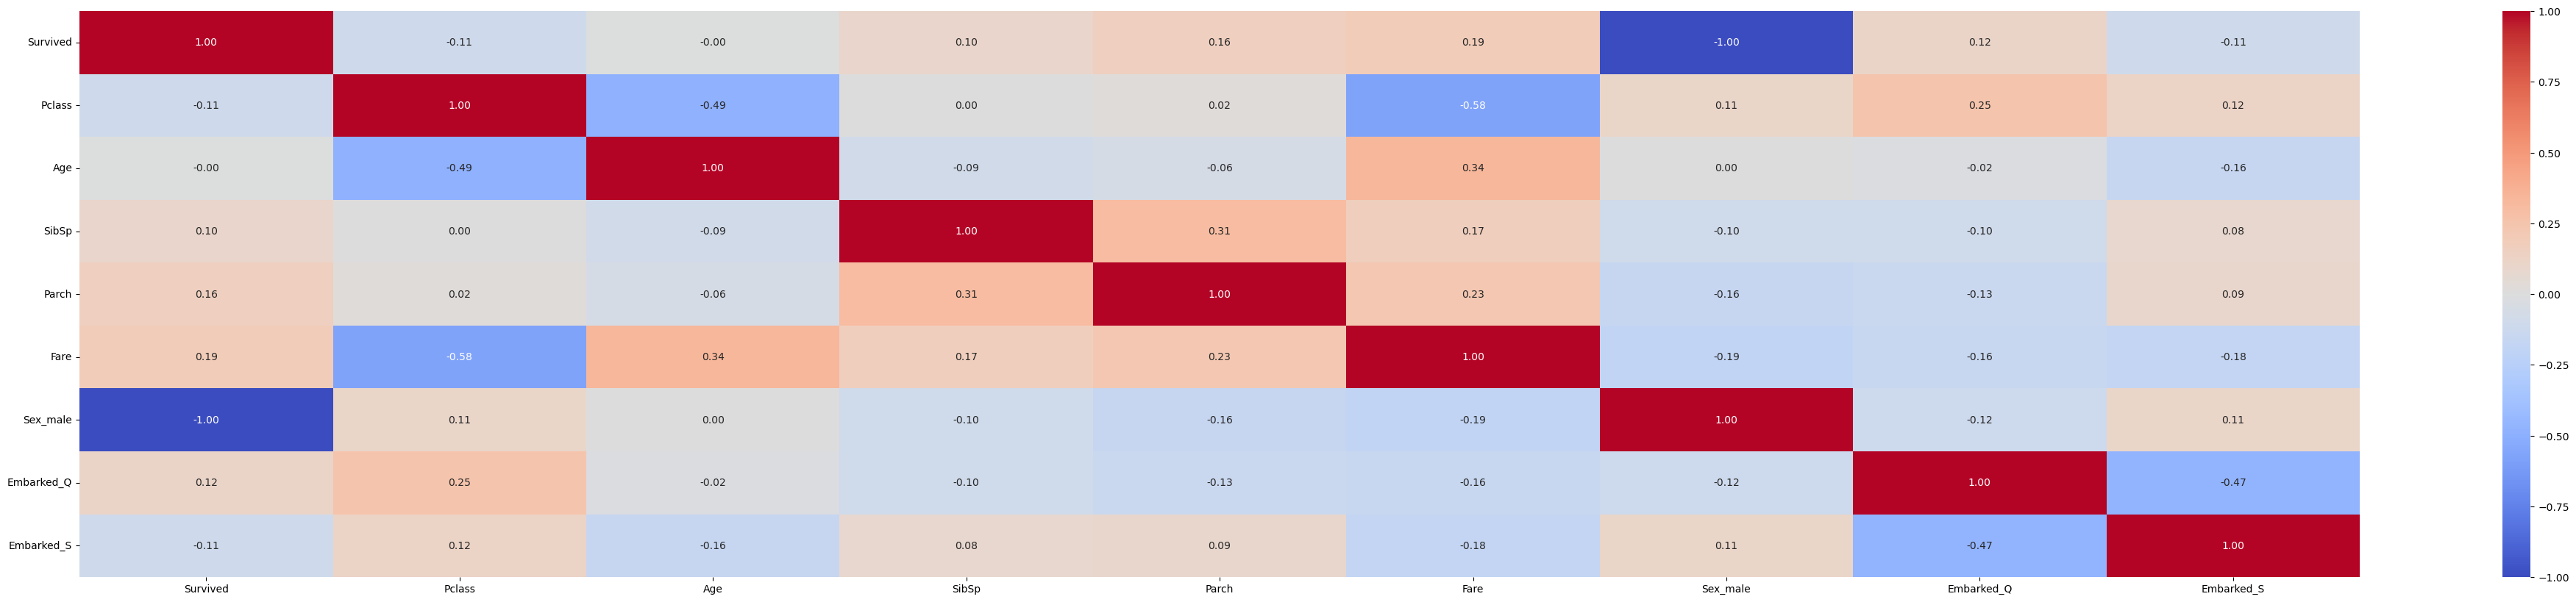

In [308]:
plt.figure(figsize = (50,10))

sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = "0.2f",
    cmap = "coolwarm"
)

In [309]:
df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Sex_male', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [310]:
numerical_cols = df.select_dtypes(include = "number").columns

In [311]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,34.5,0,0,330911,7.8292,1.0,1.0,0.0
1,1,3,47.0,1,0,363272,7.0000,0.0,0.0,1.0
2,0,2,62.0,0,0,240276,9.6875,1.0,1.0,0.0
3,0,3,27.0,0,0,315154,8.6625,1.0,0.0,1.0
4,1,3,22.0,1,1,3101298,12.2875,0.0,0.0,1.0


In [312]:
df = df.drop("Ticket",axis = 1)

In [313]:
categorical_cols = df.select_dtypes(include="object").columns

In [314]:
categorical_cols

Index([], dtype='object')

In [315]:
x.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,34.5,0,0,7.8292,1.0,1.0,0.0
1,3,47.0,1,0,7.0000,0.0,0.0,1.0
2,2,62.0,0,0,9.6875,1.0,1.0,0.0
3,3,27.0,0,0,8.6625,1.0,0.0,1.0
4,3,22.0,1,1,12.2875,0.0,0.0,1.0


In [316]:
y.head()

0    0
1    1
2    0
3    0
4    1
Name: Survived, dtype: int64

In [317]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [318]:
num_imp.fit(x_train[numerical_cols])
x_train[numerical_cols] = num_imp.transform(x_train[numerical_cols])
x_test[numerical_cols] = num_imp.transform(x_test[numerical_cols])

KeyError: "['Survived'] not in index"

In [ ]:
x = df.drop("Survived",axis = 1)
y = df["Survived"]

In [ ]:
scaler = StandardScaler()

In [ ]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(x_train_scaled,y_train)

In [ ]:
y_pred = model.predict(x_test_scaled)

In [ ]:
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precisionn score: ",precision_score(y_test,y_pred))
print("recall score: ",recall_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
model = KNeighborsClassifier(n_neighbors = 7)

In [ ]:
model.fit(x_train_scaled,y_train)

In [ ]:
y_pred = model.predict(x_test_scaled)

In [ ]:
accuracy_score(y_test,y_pred)

In [ ]:
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precisionn score: ",precision_score(y_test,y_pred))
print("recall score: ",recall_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
model = GaussianNB()

In [ ]:
model.fit(x_train,y_train)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precisionn score: ",precision_score(y_test,y_pred))
print("recall score: ",recall_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))